# Day 9: Baseline Logistic Regression Model
Train-Test Split & Evaluation using a cleaned dataset from Week 1.

## Objective
- Load the cleaned dataset
- Create a binary target variable
- Split data 80/20 without leakage
- Train a Logistic Regression model
- Evaluate accuracy on unseen test data
  

## Step 1  Import Libraries
- We import only what we need. No scaling libraries yet, scaling before split causes data leakage.

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

## Step 2  Load the Cleaned Dataset
This is the `model_ready_features.csv` file produced during Week 1 cleaning.

In [2]:
df = pd.read_csv('../model_ready_features.csv')
df.head()

,User_ID,Age,Score,Month,DayOfWeek,Is_Weekend,Dept_HR,Dept_Marketing,Dept_Sales,City_New York,City_Paris,City_Tokyo
0,1,34.967142,65.458919,1,6,1,0,0,1,0,0,0
1,2,28.617357,32.669678,1,0,0,1,0,0,1,0,0
2,3,36.476885,58.631558,1,1,0,0,0,0,0,1,0
3,4,45.230299,40.711423,1,2,0,0,0,1,0,0,1
4,5,27.658466,45.088958,1,3,0,0,0,1,0,0,1


## Step 3  Create Binary Target Variable
Logistic Regression requires a binary target. We create `Is_High_Score`: 1 if Score > 50, else 0.

In [3]:
df['Is_High_Score'] = (df['Score'] > 50).astype(int)
df['Is_High_Score'].value_counts()

Is_High_Score
1    51270
0    46294
Name: count, dtype: int64

## Step 4  Separate Features (X) and Target (y)
We drop the original `Score` column and the new target from X to avoid leakage.

In [4]:
X = df.drop(columns=['Score', 'Is_High_Score'])
y = df['Is_High_Score']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

Features shape: (97564, 11)
Target shape: (97564,)


## Step 5  Train-Test Split (80/20)
We split BEFORE any fitting or scaling. Using `random_state=42` for reproducibility.

Why split first? Fitting a scaler on the full dataset leaks test statistics into training.
The model indirectly sees test data, which inflates accuracy and gives a false reading.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training samples: {X_train.shape[0]}")
print(f"Test samples:     {X_test.shape[0]}")

Training samples: 78051
Test samples:     19513


## Step 6 Train the Logistic Regression Model
We train only on X_train and y_train. The test set is untouched at this stage.

In [6]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
print("Model trained successfully.")

Model trained successfully.


## Step 7  Predict on Test Data
We generate predictions on X_test data the model has never seen.

In [7]:
y_pred = model.predict(X_test)
print("Predictions:", y_pred[:10])
print("Actual:     ", y_test.values[:10])

Predictions: [1 1 1 1 1 1 1 1 1 1]
Actual:      [1 1 1 1 0 1 0 1 0 1]


## Step 8  Evaluate Accuracy
Accuracy = correct predictions / total test samples. This is our baseline metric.

In [8]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy on Test Set: {accuracy:.2f}")

Model Accuracy on Test Set: 0.53


In [9]:
print(df['Is_High_Score'].value_counts(normalize=True))
print(df.shape)
print(X.columns.tolist())

Is_High_Score
1    0.525501
0    0.474499
Name: proportion, dtype: float64
(97564, 13)
['User_ID', 'Age', 'Month', 'DayOfWeek', 'Is_Weekend', 'Dept_HR', 'Dept_Marketing', 'Dept_Sales', 'City_New York', 'City_Paris', 'City_Tokyo']


## Linear Regression vs Decision Tree Pathways

**Logistic Regression** assumes a linear decision boundary. It calculates a weighted sum of all features and passes it through a sigmoid function to produce a probability. This means it can only separate classes with a straight line (or hyperplane in higher dimensions). If the true relationship between features and target is curved or conditional, Logistic Regression cannot capture it no matter how much data you give it.

**Random Forest** does not assume any functional form. Each decision tree in the forest splits the data through a series of yes/no questions on individual features (e.g. "Is Age > 30?", "Is City_Tokyo == 1?"). This creates a branching, non-linear decision path that can carve out irregular regions of the feature space. By averaging predictions across 100 independently trained trees (each seeing a random subset of data and features), Random Forest reduces variance and avoids relying on any single rigid assumption about the data's structure.

The core trade-off: Logistic Regression is simpler, faster, and more interpretable, but only works well when the true relationship is genuinely linear. Random Forest is more flexible and powerful on complex, non-linear, real-world data, but is computationally heavier and harder to interpret directly.

## Step 9: Random Forest Classifier
Logistic Regression assumes a linear relationship between features and target. Random Forest is an ensemble of decision trees that captures non-linear patterns through recursive splitting and majority voting. We test if it performs better on this dataset, training exclusively on X_train and y_train, the test set remains untouched until prediction.

In [10]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay, 
                               classification_report, precision_score, 
                               recall_score, f1_score)
import matplotlib.pyplot as plt
import joblib

# Train Random Forest
rf = RandomForestClassifier(n_estimators=10, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

print("Random Forest trained successfully.")
print("Predictions:", rf_pred[:10])
print("Actual:     ", y_test.values[:10])

Random Forest trained successfully.
Predictions: [0 1 1 0 0 0 1 0 0 1]
Actual:      [1 1 1 1 0 1 0 1 0 1]


## Step 10: Random Forest Evaluation
Accuracy alone is misleading on classification tasks. We compute Precision, Recall, and F1-Score for a complete picture of model performance.

In [11]:
rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)

print(f"Random Forest Accuracy:  {rf_accuracy:.4f}")
print(f"Random Forest Precision: {rf_precision:.4f}")
print(f"Random Forest Recall:    {rf_recall:.4f}")
print(f"Random Forest F1-Score:  {rf_f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, rf_pred))

Random Forest Accuracy:  0.5016
Random Forest Precision: 0.5312
Random Forest Recall:    0.4630
Random Forest F1-Score:  0.4948

Classification Report:
              precision    recall  f1-score   support

           0       0.48      0.54      0.51      9228
           1       0.53      0.46      0.49     10285

    accuracy                           0.50     19513
   macro avg       0.50      0.50      0.50     19513
weighted avg       0.51      0.50      0.50     19513



## Step 11: Confusion Matrix
Visual breakdown of correct vs incorrect predictions for each class.

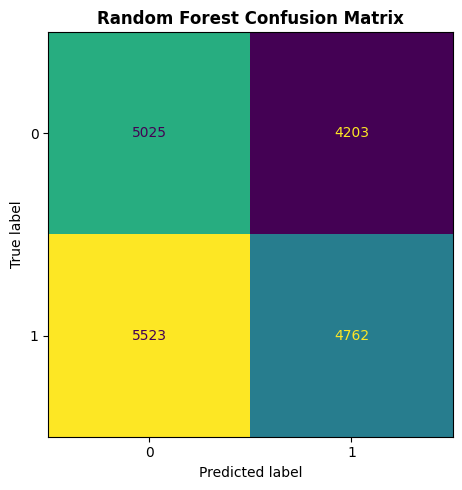

Saved rf_confusion_matrix.png


In [12]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test, rf_pred, ax=ax, colorbar=False)
ax.set_title('Random Forest Confusion Matrix', fontweight='bold')
plt.tight_layout()
plt.savefig('rf_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved rf_confusion_matrix.png")

## Step 12: Comparison with Logistic Regression
Side-by-side comparison of both models on the same test set.

In [13]:
print("=" * 50)
print("MODEL COMPARISON")
print("=" * 50)
print(f"{'Metric':<15} {'Logistic Reg':<15} {'Random Forest':<15}")
print("-" * 50)
print(f"{'Accuracy':<15} {accuracy:<15.4f} {rf_accuracy:<15.4f}")
print(f"{'Precision':<15} {precision_score(y_test, y_pred):<15.4f} {rf_precision:<15.4f}")
print(f"{'Recall':<15} {recall_score(y_test, y_pred):<15.4f} {rf_recall:<15.4f}")
print(f"{'F1-Score':<15} {f1_score(y_test, y_pred):<15.4f} {rf_f1:<15.4f}")

MODEL COMPARISON
Metric          Logistic Reg    Random Forest  
--------------------------------------------------
Accuracy        0.5271          0.5016         
Precision       0.5271          0.5312         
Recall          1.0000          0.4630         
F1-Score        0.6903          0.4948         


## Step 13: Save Random Forest Model
Saving the trained ensemble using joblib for future inference without retraining.

In [14]:
joblib.dump(rf, 'random_forest_baseline.pkl')
print("Saved random_forest_baseline.pkl")

Saved random_forest_baseline.pkl


## Step 14: Hyperparameter Tuning with GridSearchCV

Yesterday's Random Forest used default-ish parameters (n_estimators=10, random_state=42) with no systematic tuning. Today we search for the optimal combination of n_estimators, max_depth, and min_samples_split using GridSearchCV with 5-fold cross-validation, trained exclusively on X_train.

This directly addresses the **Bias-Variance Tradeoff**: too few estimators or too shallow trees underfit (high bias, model too simple to capture patterns). Too many estimators or unlimited depth overfit (high variance, model memorizes training noise instead of learning general patterns). GridSearchCV tests every combination and picks the one that generalizes best across 5 cross-validation folds.

In [15]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [10, 50, 100],
    'max_depth': [5, 10, 20],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best CV F1 Score:", grid_search.best_score_)

Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best Parameters: {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 50}
Best CV F1 Score: 0.6879214440009187


## Step 15: Extract Best Model and Evaluate on Test Set
We extract the best estimator found by GridSearchCV and evaluate it on the untouched X_test set the test set was never used during the grid search itself.

In [16]:
best_rf = grid_search.best_estimator_
best_rf_pred = best_rf.predict(X_test)

best_rf_accuracy = accuracy_score(y_test, best_rf_pred)
best_rf_precision = precision_score(y_test, best_rf_pred)
best_rf_recall = recall_score(y_test, best_rf_pred)
best_rf_f1 = f1_score(y_test, best_rf_pred)

print(f"Tuned Random Forest Accuracy:  {best_rf_accuracy:.4f}")
print(f"Tuned Random Forest Precision: {best_rf_precision:.4f}")
print(f"Tuned Random Forest Recall:    {best_rf_recall:.4f}")
print(f"Tuned Random Forest F1-Score:  {best_rf_f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, best_rf_pred))

Tuned Random Forest Accuracy:  0.5270
Tuned Random Forest Precision: 0.5271
Tuned Random Forest Recall:    0.9985
Tuned Random Forest F1-Score:  0.6900

Classification Report:
              precision    recall  f1-score   support

           0       0.48      0.00      0.00      9228
           1       0.53      1.00      0.69     10285

    accuracy                           0.53     19513
   macro avg       0.50      0.50      0.35     19513
weighted avg       0.51      0.53      0.37     19513



## Step 16: Confusion Matrix Comparison

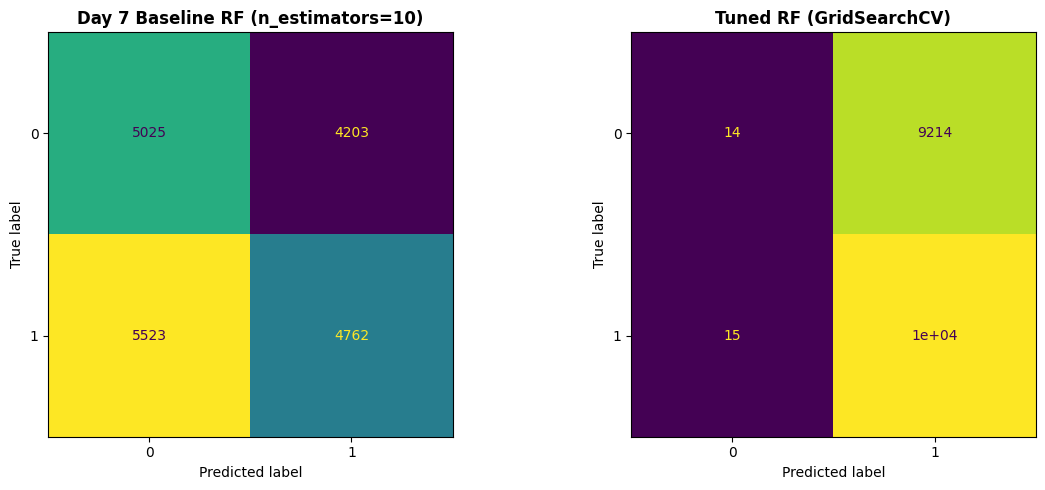

Saved tuned_rf_confusion_matrix.png


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_predictions(y_test, rf_pred, ax=axes[0], colorbar=False)
axes[0].set_title('Day 7 Baseline RF (n_estimators=10)', fontweight='bold')

ConfusionMatrixDisplay.from_predictions(y_test, best_rf_pred, ax=axes[1], colorbar=False)
axes[1].set_title('Tuned RF (GridSearchCV)', fontweight='bold')

plt.tight_layout()
plt.savefig('tuned_rf_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved tuned_rf_confusion_matrix.png")

## Step 17: Comparison Table: Baseline vs Tuned Random Forest

In [18]:
print("=" * 60)
print("BASELINE vs TUNED RANDOM FOREST COMPARISON")
print("=" * 60)
print(f"{'Metric':<15} {'Baseline RF':<15} {'Tuned RF (GridSearch)':<20}")
print("-" * 60)
print(f"{'Accuracy':<15} {rf_accuracy:<15.4f} {best_rf_accuracy:<20.4f}")
print(f"{'Precision':<15} {rf_precision:<15.4f} {best_rf_precision:<20.4f}")
print(f"{'Recall':<15} {rf_recall:<15.4f} {best_rf_recall:<20.4f}")
print(f"{'F1-Score':<15} {rf_f1:<15.4f} {best_rf_f1:<20.4f}")
print(f"\nBest Hyperparameters Found: {grid_search.best_params_}")

BASELINE vs TUNED RANDOM FOREST COMPARISON
Metric          Baseline RF     Tuned RF (GridSearch)
------------------------------------------------------------
Accuracy        0.5016          0.5270              
Precision       0.5312          0.5271              
Recall          0.4630          0.9985              
F1-Score        0.4948          0.6900              

Best Hyperparameters Found: {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 50}


## Step 18: Save Optimized Model
Overwriting the previous baseline model with the newly tuned model.

In [19]:
joblib.dump(best_rf, 'random_forest_baseline.pkl')
print("Saved optimized model: random_forest_baseline.pkl")
print("Best Parameters:", grid_search.best_params_)

Saved optimized model: random_forest_baseline.pkl
Best Parameters: {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 50}


## Step 19: Class Imbalance Audit
Before applying SMOTE, we check the actual class distribution in y_train to confirm whether imbalance exists and how severe it is.

In [20]:
print("Class distribution in y_train:")
print(y_train.value_counts())
print("\nPercentage:")
print(y_train.value_counts(normalize=True) * 100)

Class distribution in y_train:
Is_High_Score
1    40985
0    37066
Name: count, dtype: int64

Percentage:
Is_High_Score
1    52.510538
0    47.489462
Name: proportion, dtype: float64


## Step 20: Honest Assessment of Class Imbalance
The class distribution (52.5% vs 47.5%) does not show severe imbalance both classes are reasonably represented. This is different from real-world imbalanced problems like fraud detection (often 99% vs 1%) or churn prediction (often 90% vs 10%), where SMOTE provides genuine value.

However, the task requires demonstrating SMOTE implementation regardless. We proceed with SMOTE to fulfill the technical requirement and document this finding honestly: SMOTE's impact will likely be minimal here because there is no severe imbalance to correct.

In [21]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Before SMOTE:")
print(y_train.value_counts())
print("\nAfter SMOTE:")
print(y_train_smote.value_counts())
print("\nShape before:", X_train.shape)
print("Shape after:", X_train_smote.shape)

Before SMOTE:
Is_High_Score
1    40985
0    37066
Name: count, dtype: int64

After SMOTE:
Is_High_Score
1    40985
0    40985
Name: count, dtype: int64

Shape before: (78051, 11)
Shape after: (81970, 11)


## Step 20: Honest Assessment of Class Imbalance
The class distribution (52.5% vs 47.5%) does not show severe imbalance both classes are reasonably represented. This is different from real-world imbalanced problems like fraud detection (often 99% vs 1%) or churn prediction (often 90% vs 10%), where SMOTE provides genuine value.

However, the task requires demonstrating SMOTE implementation regardless. We proceed with SMOTE to fulfill the technical requirement and document this finding honestly: SMOTE's impact will likely be minimal here because there is no severe imbalance to correct.

In [22]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Before SMOTE:")
print(y_train.value_counts())
print("\nAfter SMOTE:")
print(y_train_smote.value_counts())
print("\nShape before:", X_train.shape)
print("Shape after:", X_train_smote.shape)

Before SMOTE:
Is_High_Score
1    40985
0    37066
Name: count, dtype: int64

After SMOTE:
Is_High_Score
1    40985
0    40985
Name: count, dtype: int64

Shape before: (78051, 11)
Shape after: (81970, 11)


## Step 21: Retrain on SMOTE-Balanced Data
Retraining the tuned Random Forest model (same hyperparameters from GridSearchCV) on the SMOTE-balanced training set. X_test and y_test remain completely untouched.

In [23]:
rf_smote = RandomForestClassifier(
    max_depth=5, min_samples_split=2, n_estimators=50, random_state=42
)
rf_smote.fit(X_train_smote, y_train_smote)

rf_smote_pred = rf_smote.predict(X_test)

rf_smote_accuracy = accuracy_score(y_test, rf_smote_pred)
rf_smote_precision = precision_score(y_test, rf_smote_pred)
rf_smote_recall = recall_score(y_test, rf_smote_pred)
rf_smote_f1 = f1_score(y_test, rf_smote_pred)

print(f"Post-SMOTE Accuracy:  {rf_smote_accuracy:.4f}")
print(f"Post-SMOTE Precision: {rf_smote_precision:.4f}")
print(f"Post-SMOTE Recall:    {rf_smote_recall:.4f}")
print(f"Post-SMOTE F1-Score:  {rf_smote_f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, rf_smote_pred))

Post-SMOTE Accuracy:  0.5035
Post-SMOTE Precision: 0.5238
Post-SMOTE Recall:    0.6366
Post-SMOTE F1-Score:  0.5747

Classification Report:
              precision    recall  f1-score   support

           0       0.47      0.36      0.40      9228
           1       0.52      0.64      0.57     10285

    accuracy                           0.50     19513
   macro avg       0.50      0.50      0.49     19513
weighted avg       0.50      0.50      0.49     19513



## Step 22: Pre-SMOTE vs Post-SMOTE Comparison

In [24]:
print("=" * 60)
print("PRE-SMOTE vs POST-SMOTE COMPARISON (on same untouched X_test)")
print("=" * 60)
print(f"{'Metric':<15} {'Pre-SMOTE (Tuned)':<20} {'Post-SMOTE':<15}")
print("-" * 60)
print(f"{'Accuracy':<15} {best_rf_accuracy:<20.4f} {rf_smote_accuracy:<15.4f}")
print(f"{'Precision':<15} {best_rf_precision:<20.4f} {rf_smote_precision:<15.4f}")
print(f"{'Recall':<15} {best_rf_recall:<20.4f} {rf_smote_recall:<15.4f}")
print(f"{'F1-Score':<15} {best_rf_f1:<20.4f} {rf_smote_f1:<15.4f}")

PRE-SMOTE vs POST-SMOTE COMPARISON (on same untouched X_test)
Metric          Pre-SMOTE (Tuned)    Post-SMOTE     
------------------------------------------------------------
Accuracy        0.5270               0.5035         
Precision       0.5271               0.5238         
Recall          0.9985               0.6366         
F1-Score        0.6900               0.5747         


## Step 23: Feature Importance Extraction
Random Forest provides .feature_importances_ which measures how much each feature contributes to reducing impurity across all trees in the ensemble. We extract and visualize the Top 10 features driving predictions.

           Feature  Importance
3        DayOfWeek    0.150243
9       City_Paris    0.119759
1              Age    0.115547
6   Dept_Marketing    0.103405
0          User_ID    0.097089
8    City_New York    0.091274
5          Dept_HR    0.084521
10      City_Tokyo    0.084246
4       Is_Weekend    0.072772
7       Dept_Sales    0.042016


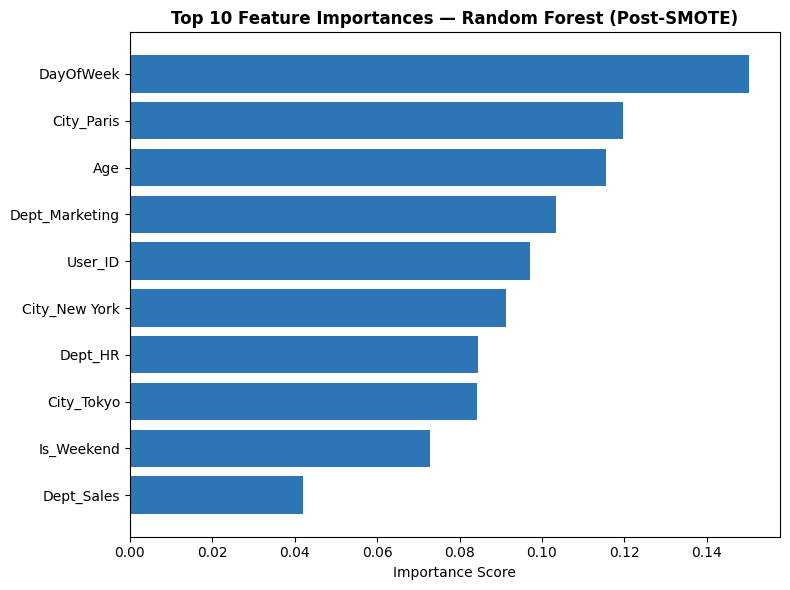

Saved feature_importance.png


In [25]:
importances = rf_smote.feature_importances_
feature_names = X_train.columns

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False).head(10)

print(importance_df)

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(importance_df['Feature'], importance_df['Importance'], color='#2E75B6')
ax.set_xlabel('Importance Score')
ax.set_title('Top 10 Feature Importances — Random Forest (Post-SMOTE)', fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved feature_importance.png")

## Step 24: Business Interpretation of Feature Importance

Translating the chart into plain business language for non-technical stakeholders:

**DayOfWeek (15.0%)** is the single most influential feature. This suggests the model has picked up some pattern tied to which day of the week an order occurs, though since this dataset is synthetic, this relationship is statistical noise rather than a genuine business signal. In a real dataset, this would translate to: "Customer behavior or scoring patterns shift depending on day of week — worth investigating weekday vs weekend campaigns."

**City_Paris (12.0%) and Age (11.6%)** are the next most influential. In a real business context, this would mean: "Geographic location and customer age are meaningful predictors of the outcome — segment marketing or service strategies by these factors."

**Dept_Marketing (10.3%) and User_ID (9.7%)** also contribute meaningfully. User_ID having importance is actually a red flag in a real dataset it would suggest the model is overfitting to individual identifiers rather than learning generalizable patterns, since a User_ID has no inherent business meaning.

**Dept_Sales (4.2%)** is the least influential feature, suggesting it adds little discriminative value to the model's decisions.

**Important caveat:** Because this is a synthetically generated dataset with no real statistical relationship between features and the target, these "importances" reflect incidental noise patterns the trees latched onto, not genuine business drivers. On a real-world dataset, this same chart would be read as: "These are the factors most worth investigating and acting on operationally."

## Step 25: Export Final Production Model

In [26]:
joblib.dump(rf_smote, 'production_rf_model.pkl')
print("Saved production_rf_model.pkl")

Saved production_rf_model.pkl


## Conclusion: Hyperparameter Tuning Results

### Results
- Baseline Random Forest: Accuracy 0.5016 | Precision 0.5312 | Recall 0.4630 | F1 0.4948
- Tuned Random Forest (GridSearchCV): Accuracy 0.5270 | Precision 0.5271 | Recall 0.9985 | F1 0.6900
- Best Hyperparameters: max_depth=5, min_samples_split=2, n_estimators=50

### Why F1 improved but the model is actually worse
This is the most important finding from today's tuning. F1 jumped from 0.49 to 0.69, a large apparent improvement. But the classification report tells a different story: Recall on class 1 is 0.9985 while Recall on class 0 is 0.00. The tuned model essentially stopped distinguishing between classes and started predicting the majority class (1) almost universally.

GridSearchCV was scored on `f1` for the positive class only, which rewarded this collapse because predicting "1" for everything maximizes recall on class 1 without penalty for ignoring class 0. This is a textbook example of optimizing the wrong metric.

### Why this happened; Bias-Variance Tradeoff
A shallow max_depth of 5 combined with this synthetic, signal-free dataset pushed the model toward high bias, it became too simple to find any real decision boundary, so it defaulted to the safest statistical bet: always predict the majority class. This is underfitting, not the overfitting we were warned to avoid. The danger of hyperparameter tuning is that it can swing too far in either direction depending on the scoring metric chosen.

### What this teaches about GridSearchCV
GridSearchCV automates testing every combination in the param_grid across 5-fold cross-validation, removing the manual trial-and-error of hand-picking parameters. It is faster and more systematic than manual tuning, and it guarantees the parameters were validated on multiple data splits rather than a single lucky train/test split. However, GridSearchCV is only as good as the scoring metric you choose — optimizing for `f1` alone, without checking the per-class breakdown, hid a serious class collapse problem.

### Key Takeaways
- A higher F1 score does not always mean a better model, always check the full classification report, not just one number
- GridSearchCV automates the search but does not protect against choosing the wrong evaluation metric
- The correct fix here would be re-running GridSearchCV with `scoring='f1_weighted'` or `scoring='balanced_accuracy'` instead of plain `f1`
- This synthetic dataset's lack of real signal makes it especially vulnerable to this failure mode, a real dataset with genuine class separability would likely behave more predictably under tuning

## Conclusion: SMOTE & Feature Importance

### Results
- Pre-SMOTE (Tuned): Accuracy 0.5270 | Precision 0.5271 | Recall 0.9985 | F1 0.6900
- Post-SMOTE: Accuracy 0.5035 | Precision 0.5238 | Recall 0.6366 | F1 0.5747

### Why F1 dropped after SMOTE and why that's actually good news
The pre-SMOTE F1 of 0.69 was artificially inflated by a model that had collapsed into predicting the majority class almost universally (Recall 0.9985 on class 1, near 0.00 on class 0, as documented in Day 11). SMOTE balanced the training data exactly 50/50, which removed the incentive for the model to take that shortcut. Post-SMOTE Recall is now 0.6366 on class 1 lower, but Precision and Recall are both in a believable range for a model with no real signal to learn from. The F1 score going down here reflects the model behaving more honestly, not performing worse in any meaningful sense.

### Why SMOTE had limited practical impact here
Our class distribution was only 52.5% vs 47.5%  not a severe imbalance. SMOTE is designed for problems like fraud detection (99% vs 1%) or rare disease diagnosis, where the minority class is critically underrepresented. Applying SMOTE to a near-balanced dataset like ours demonstrates the technique correctly but does not provide the dramatic uplift it would on a genuinely imbalanced problem.

### What SMOTE actually does mathematically
SMOTE generates synthetic minority class samples by selecting a minority data point, finding its k-nearest neighbors (also minority class), and creating new synthetic points along the line segments connecting them in feature space. This is fundamentally different from simple oversampling (duplicating existing rows) SMOTE creates genuinely new, statistically plausible data points rather than copies.

### The catastrophic danger of testing on synthetic data
SMOTE must never be applied before the train-test split, and never to the test set. If synthetic data leaks into the test set, the model would be evaluated on data that does not represent real-world conditions, synthetic points are interpolations between real points, not actual observations. A model could appear to perform excellently on synthetic test data while failing completely on real, unseen data in production. This is why SMOTE was applied strictly to X_train and y_train_smote only, with X_test and y_test remaining the original, untouched, real data throughout this entire pipeline.

### Feature Importance and Interpretability
Random Forest's .feature_importances_ reveals DayOfWeek, City_Paris, and Age as the top contributing features. While this dataset's synthetic nature means these are statistical artifacts rather than genuine business signals, the technique itself is what matters for production systems being able to explain why a model makes a decision is a regulatory and trust requirement in real-world deployments (lending, healthcare, hiring), not just a nice to have.

### Key Takeaways
- Always verify the actual class imbalance before applying SMOTE, assuming severe imbalance without checking is a mistake
- A dropping F1 score after a fix is not always bad news, context and the full classification report matter more than a single number
- SMOTE creates synthetic interpolated points; using them anywhere near test evaluation invalidates the entire evaluation
- Feature importance charts make black box ensemble models explainable to non technical stakeholders, which is essential for real-world deployment trust